# Step 1c — Optical flood reference

Spec: `CLAUDE.md` §6 step 1c (added 2026-09-15). **Sentinel-2 only. No Sentinel-1 data is used
anywhere in this notebook**, because every ready-made SAR flood product for this event is derived
from Sentinel-1 and would make the Step 2 validation circular.

1. Every Sentinel-2 acquisition over the study area, 11–25 March 2023, with its clear-pixel
   fraction (Cloud Score+ `cs_cdf` > 0.6).
2. For the clearest post-event date: NDWI = (B3 − B8)/(B3 + B8) and MNDWI = (B3 − B11)/(B3 + B11),
   against a pre-event baseline composite (1 Feb – 8 Mar 2023).
3. A candidate standing-water mask over the two counties, excluding permanent water
   (`JRC/GSW1_4/GlobalSurfaceWater` occurrence > 50), exported as polygons.
4. A figure: pre-event composite, post-event composite, derived water mask.

Limitations (recorded in `CLAUDE.md` §8): the clear pass is several days after the 10–11 March
peak, so water has partly receded and this reference **under-counts** flooded area, which biases
against the method rather than for it; cloud during the peak is why no optical observation exists at
maximum inundation; and this is a mask derived here, not a surveyed extent, so it carries its own
error.

Aggregate figures for sanity checks are in `docs/ground_truth_aggregate.md`. January and March 2023
are kept strictly separate; the event window here is March.

**CHECKPOINT:** the figure and the acquisition date table. Stop before Step 2.

In [1]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

import common as C
from maps import HALO, add_north_arrow, add_scale_bar, ee_tif

ee.Initialize(project=C.EE_PROJECT)

POST_WINDOW = ("2023-03-11", "2023-03-26")   # 11-25 March 2023 inclusive
PRE_WINDOW = ("2023-02-01", "2023-03-09")    # 1 Feb - 8 Mar 2023 inclusive
AOI_LL = (-121.90, 36.60, -121.55, 36.98)    # Pajaro Valley to northern Salinas Valley
ACRE_M2 = 4046.8564224

counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
counties = gpd.GeoDataFrame.from_features(counties_fc.getInfo()["features"], crs="EPSG:4326")
counties = counties[["GEOID", "NAME", "geometry"]].sort_values("GEOID").reset_index(drop=True)
counties_m = counties.to_crs(C.GRID_CRS)
towns = gpd.GeoDataFrame({"name": list(C.TOWNS)}, crs="EPSG:4326",
                         geometry=gpd.points_from_xy(*zip(*C.TOWNS.values()))).to_crs(C.GRID_CRS)
units = gpd.read_file(C.DERIVED / "01_units_dwr.geojson")
units = units[units.is_unit.astype(bool)]
N_UNITS = len(units)


def stamp(window):
    print(f"n units = {N_UNITS} | date window: {window} | datasets: {C.S2}, {C.S2_CLOUD} "
          f"(cs_cdf > {C.CLEAR_CS_CDF}), {C.GSW}")


def clear_s2(start, end):
    # Sentinel-2 SR over the study area, Cloud Score+ linked, cloudy pixels masked
    return (ee.ImageCollection(C.S2).filterBounds(region).filterDate(start, end)
            .linkCollection(ee.ImageCollection(C.S2_CLOUD), ["cs_cdf"])
            .map(lambda im: im.updateMask(im.select("cs_cdf").gt(C.CLEAR_CS_CDF))))


print("Sentinel-1 is not used in this notebook.")
print(f"post window {POST_WINDOW[0]} to 2023-03-25 | pre window {PRE_WINDOW[0]} to 2023-03-08 | "
      f"n units = {N_UNITS}")

Sentinel-1 is not used in this notebook.
post window 2023-03-11 to 2023-03-25 | pre window 2023-02-01 to 2023-03-08 | n units = 1320


## 1. Sentinel-2 acquisitions, 11-25 March 2023

In [2]:
post_raw = (ee.ImageCollection(C.S2).filterBounds(region).filterDate(*POST_WINDOW)
            .linkCollection(ee.ImageCollection(C.S2_CLOUD), ["cs_cdf"]))


def scene_row(im):
    clear = im.select("cs_cdf").gt(C.CLEAR_CS_CDF)
    frac = clear.reduceRegion(ee.Reducer.mean(), im.geometry().intersection(region, 100),
                              scale=200, maxPixels=1e9, bestEffort=True).get("cs_cdf")
    return ee.Feature(None, {"date": im.date().format("YYYY-MM-dd"), "tile": im.get("MGRS_TILE"),
                             "scene_cloud_pct": im.get("CLOUDY_PIXEL_PERCENTAGE"),
                             "clear_frac_scene": frac})


scenes = pd.DataFrame([f["properties"] for f in post_raw.map(scene_row).getInfo()["features"]])
scenes["clear_frac_scene"] = scenes.clear_frac_scene.astype(float).round(3)
scenes["scene_cloud_pct"] = scenes.scene_cloud_pct.astype(float).round(1)
print("Scenes intersecting the two counties:")
print(scenes.sort_values(["date", "tile"]).to_string(index=False))

rows = []
for d in sorted(scenes.date.unique()):
    day = post_raw.filterDate(d, ee.Date(d).advance(1, "day"))
    clear = day.map(lambda im: im.select("cs_cdf").gt(C.CLEAR_CS_CDF)).mosaic()
    frac = clear.unmask(0).reduceRegion(ee.Reducer.mean(), region, scale=200, maxPixels=1e9,
                                        bestEffort=True).get("cs_cdf").getInfo()
    rows.append({"date": d, "scenes": int(day.size().getInfo()),
                 "clear_frac_study_area": round(float(frac), 3)})
acq = pd.DataFrame(rows).sort_values("date")
print("\nBy date, clear fraction of the whole two-county study area:")
print(acq.to_string(index=False))

BEST = acq.loc[acq.clear_frac_study_area.idxmax(), "date"]
print(f"\nClearest post-event date: {BEST} ({acq.clear_frac_study_area.max():.1%} of the study area clear)")

ACQ_CSV = C.DERIVED / "01c_s2_acquisitions.csv"
if ACQ_CSV.exists():
    print(f"{ACQ_CSV.name} exists; not overwritten")
else:
    tiles = scenes.groupby("date").tile.apply(lambda s: " ".join(sorted(s))).rename("tiles")
    acq.merge(tiles, on="date", how="left").to_csv(ACQ_CSV, index=False)
    print(f"Wrote {ACQ_CSV.name}")
stamp(f"{POST_WINDOW[0]} to 2023-03-25")

Scenes intersecting the two counties:
 clear_frac_scene       date  scene_cloud_pct  tile
            0.001 2023-03-12             98.9 10SFE
            0.051 2023-03-12             97.4 10SFF
            0.088 2023-03-12             62.5 10SGE
            0.000 2023-03-12             92.3 10SGF
            0.104 2023-03-12             46.4 11SKV
            0.796 2023-03-15              6.9 10SEF
            0.586 2023-03-15             17.1 10SEG
            0.762 2023-03-15             56.0 10SFE
            0.894 2023-03-15             15.7 10SFF
            0.221 2023-03-15             70.0 10SFG
            0.963 2023-03-15              3.7 10SGE
            0.821 2023-03-15             24.6 10SGF
            0.618 2023-03-17             54.0 10SFE
            0.703 2023-03-17             41.2 10SFF
            0.641 2023-03-17             56.8 10SGE
            0.725 2023-03-17             49.9 10SGF
            0.788 2023-03-17             59.6 11SKV
            0.492 2023-03-


By date, clear fraction of the whole two-county study area:
      date  scenes  clear_frac_study_area
2023-03-12       5                  0.022
2023-03-15       7                  0.748
2023-03-17       5                  0.345
2023-03-20       7                  0.205
2023-03-22       5                  0.001
2023-03-25       7                  0.907

Clearest post-event date: 2023-03-25 (90.7% of the study area clear)
Wrote 01c_s2_acquisitions.csv
n units = 1320 | date window: 2023-03-11 to 2023-03-25 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), JRC/GSW1_4/GlobalSurfaceWater


## 2. Water indices, clearest post-event date vs the pre-event baseline

NDWI and MNDWI are computed at 20 m, the native resolution of B11, in EPSG:3310.

In [3]:
def water_indices(img):
    ndwi = img.normalizedDifference(["B3", "B8"]).rename("ndwi")
    mndwi = img.normalizedDifference(["B3", "B11"]).rename("mndwi")
    return ndwi.addBands(mndwi)


pre = water_indices(clear_s2(*PRE_WINDOW).median())
post_col = clear_s2(BEST, ee.Date(BEST).advance(1, "day").format("YYYY-MM-dd"))
post = water_indices(post_col.mosaic())
d_mndwi = post.select("mndwi").subtract(pre.select("mndwi")).rename("d_mndwi")

NDWI_MIN, MNDWI_MIN, D_MNDWI_MIN = 0.0, 0.0, 0.2
perm_water = ee.Image(C.GSW).select("occurrence").unmask(0).gt(C.PERMANENT_WATER)
water = (post.select("ndwi").gt(NDWI_MIN)
         .And(post.select("mndwi").gt(MNDWI_MIN))
         .And(d_mndwi.gt(D_MNDWI_MIN))
         .And(perm_water.Not())
         .rename("water").selfMask())

by_county = ee.Image.pixelArea().updateMask(water).reduceRegions(counties_fc, ee.Reducer.sum(),
                                                                scale=20).getInfo()
areas = {f["properties"]["NAME"]: f["properties"]["sum"] / ACRE_M2 for f in by_county["features"]}
print(f"Thresholds: NDWI > {NDWI_MIN}, MNDWI > {MNDWI_MIN}, MNDWI rise over baseline > {D_MNDWI_MIN}; "
      f"permanent water ({C.GSW} occurrence > {C.PERMANENT_WATER}) removed.")
print(f"Candidate standing water on {BEST}, acres by county: "
      + ", ".join(f"{k}: {v:,.0f}" for k, v in areas.items())
      + f" | total {sum(areas.values()):,.0f} acres")
stamp(f"post {BEST}; pre {PRE_WINDOW[0]} to 2023-03-08")

Thresholds: NDWI > 0.0, MNDWI > 0.0, MNDWI rise over baseline > 0.2; permanent water (JRC/GSW1_4/GlobalSurfaceWater occurrence > 50) removed.
Candidate standing water on 2023-03-25, acres by county: Santa Cruz: 249, Monterey: 2,073 | total 2,321 acres
n units = 1320 | date window: post 2023-03-25; pre 2023-02-01 to 2023-03-08 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), JRC/GSW1_4/GlobalSurfaceWater


## 3. Water mask as polygons

In [4]:
MASK_GEOJSON = C.DERIVED / "01c_optical_water_mask.geojson"
if MASK_GEOJSON.exists():
    flood = gpd.read_file(MASK_GEOJSON)
    print(f"Loaded cached {MASK_GEOJSON.name} (delete it to recompute)")
else:
    vec = water.toInt().reduceToVectors(geometry=region, scale=20, crs=C.GRID_CRS,
                                        geometryType="polygon", eightConnected=True,
                                        labelProperty="water", maxPixels=1e10, tileScale=8)
    vec = vec.map(lambda f: f.set("area_ha", f.geometry().area(10).divide(1e4)))
    for min_ha in (0.2, 0.5, 1.0):
        kept = vec.filter(ee.Filter.gte("area_ha", min_ha))
        n = kept.size().getInfo()
        print(f"  polygons >= {min_ha} ha: {n}")
        if n < 4500:
            break
    flood = gpd.GeoDataFrame.from_features(kept.getInfo()["features"], crs="EPSG:4326")
    flood = flood.drop(columns=["water"]).assign(min_ha=min_ha, post_date=BEST)
    flood.to_file(MASK_GEOJSON, driver="GeoJSON")
    print(f"Wrote {MASK_GEOJSON.name} ({len(flood)} polygons, minimum {min_ha} ha)")

flood_m = flood.to_crs(C.GRID_CRS)
print(f"polygons: {len(flood_m)} | mapped water: {flood_m.area.sum() / ACRE_M2:,.0f} acres "
      f"({flood_m.area.sum() / 1e6:,.1f} km2) | largest: {flood_m.area.max() / ACRE_M2:,.0f} acres")
stamp(f"post {BEST}; pre {PRE_WINDOW[0]} to 2023-03-08")

  polygons >= 0.2 ha: 523


Wrote 01c_optical_water_mask.geojson (523 polygons, minimum 0.2 ha)
polygons: 523 | mapped water: 1,988 acres (8.0 km2) | largest: 170 acres
n units = 1320 | date window: post 2023-03-25; pre 2023-02-01 to 2023-03-08 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), JRC/GSW1_4/GlobalSurfaceWater


## 4. Figure — pre-event, post-event, derived water mask

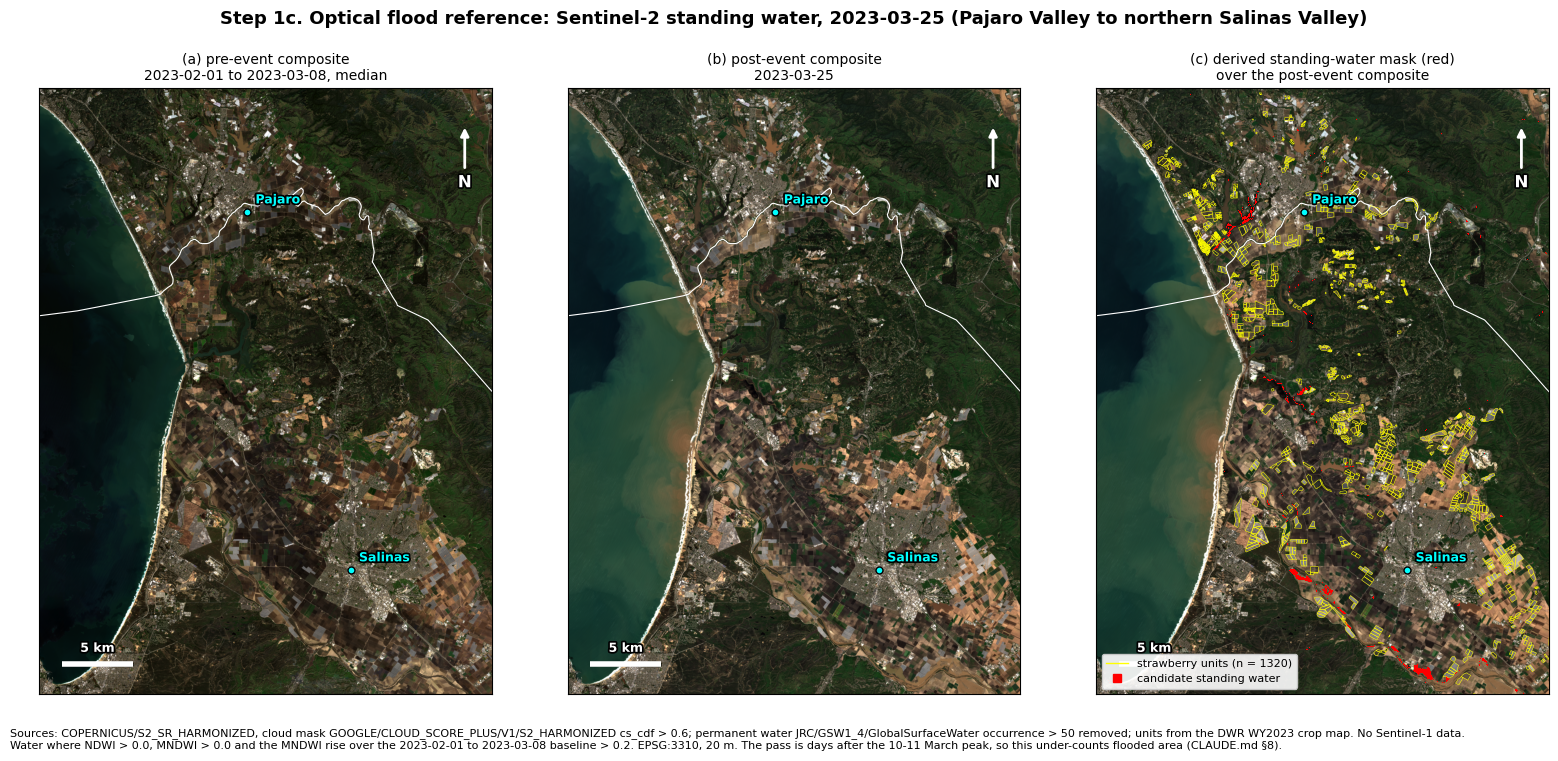

Saved fig_step1c_optical_flood_reference.png | mapped water 1,988 acres in the two counties
n units = 1320 | date window: post 2023-03-25; pre 2023-02-01 to 2023-03-08 | datasets: COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED (cs_cdf > 0.6), JRC/GSW1_4/GlobalSurfaceWater


In [5]:
VIS = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 0.3}
pre_rgb, ext = ee_tif(clear_s2(*PRE_WINDOW).median().multiply(0.0001).visualize(**VIS),
                      C.DERIVED / "01c_pre_rgb.tif", AOI_LL, 20)
post_rgb, _ = ee_tif(post_col.mosaic().multiply(0.0001).visualize(**VIS),
                     C.DERIVED / "01c_post_rgb.tif", AOI_LL, 20)
water_arr, _ = ee_tif(water.unmask(0).toByte(), C.DERIVED / "01c_water_mask_20m.tif", AOI_LL, 20)

fig, axes = plt.subplots(1, 3, figsize=(16, 7.6))
panels = [(axes[0], pre_rgb, f"(a) pre-event composite\n{PRE_WINDOW[0]} to 2023-03-08, median"),
          (axes[1], post_rgb, f"(b) post-event composite\n{BEST}"),
          (axes[2], post_rgb, "(c) derived standing-water mask (red)\nover the post-event composite")]
for ax, rgb, title in panels:
    ax.imshow(rgb, extent=ext, origin="upper")
    counties_m.boundary.plot(ax=ax, color="white", lw=0.8)
    for _, t in towns.iterrows():
        ax.plot(t.geometry.x, t.geometry.y, marker="o", ms=5, color="cyan", mec="black")
        ax.annotate(t["name"], (t.geometry.x, t.geometry.y), xytext=(6, 6), textcoords="offset points",
                    color="cyan", fontsize=9, fontweight="bold", path_effects=HALO)
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    add_scale_bar(ax, 5)
    add_north_arrow(ax)

axes[2].imshow(np.ma.masked_equal(water_arr, 0), extent=ext, origin="upper",
               cmap=ListedColormap(["red"]), interpolation="nearest")
units.to_crs(C.GRID_CRS).boundary.plot(ax=axes[2], color="yellow", lw=0.35)
axes[2].plot([], [], color="yellow", lw=1, label=f"strawberry units (n = {N_UNITS})")
axes[2].plot([], [], "s", color="red", label="candidate standing water")
axes[2].legend(loc="lower left", fontsize=8, framealpha=0.9)

fig.suptitle(f"Step 1c. Optical flood reference: Sentinel-2 standing water, {BEST} "
             "(Pajaro Valley to northern Salinas Valley)", fontsize=13, fontweight="bold")
fig.text(0.01, 0.005,
         f"Sources: {C.S2}, cloud mask {C.S2_CLOUD} cs_cdf > {C.CLEAR_CS_CDF}; permanent water {C.GSW} "
         f"occurrence > {C.PERMANENT_WATER} removed; units from the DWR WY2023 crop map. No Sentinel-1 data.\n"
         f"Water where NDWI > {NDWI_MIN}, MNDWI > {MNDWI_MIN} and the MNDWI rise over the "
         f"{PRE_WINDOW[0]} to 2023-03-08 baseline > {D_MNDWI_MIN}. EPSG:3310, 20 m. The pass is days after "
         "the 10-11 March peak, so this under-counts flooded area (CLAUDE.md §8).",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.06, 1, 0.94))
FIG = C.FIGURES / "fig_step1c_optical_flood_reference.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name} | mapped water {flood_m.area.sum() / ACRE_M2:,.0f} acres in the two counties")
stamp(f"post {BEST}; pre {PRE_WINDOW[0]} to 2023-03-08")